## THIN FILE LOAN AWARDING SYSTEM

## Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

pd.set_option('display.max_columns', 50)


## EDA

In [5]:
df = pd.read_csv('data/thin_file_credit_data.csv')
df.head()

,user_id,device_age_days,sim_swap_count_3m,avg_monthly_inflow,inflow_volatility,utility_bill_payment_ratio,airtime_topup_freq_pm,avg_airtime_topup_val,default_within_30_days
0,user_100000,132,0,14906.14,0.318,0.755,17,89.75,0
1,user_100001,465,0,7707.18,0.740,0.581,13,80.04,0
2,user_100002,890,0,2678.16,0.734,0.928,21,46.93,0
3,user_100003,300,0,12614.38,0.629,0.584,17,25.10,0
4,user_100004,136,0,5341.46,0.066,0.592,9,114.63,0


In [6]:
# Map the target variable to string for clearer legends in plots
df['repayment_status'] = df['default_within_30_days'].map({0: 'Repaid', 1: 'Defaulted'})

In [7]:
df.head()

,user_id,device_age_days,sim_swap_count_3m,avg_monthly_inflow,inflow_volatility,utility_bill_payment_ratio,airtime_topup_freq_pm,avg_airtime_topup_val,default_within_30_days,repayment_status
0,user_100000,132,0,14906.14,0.318,0.755,17,89.75,0,Repaid
1,user_100001,465,0,7707.18,0.740,0.581,13,80.04,0,Repaid
2,user_100002,890,0,2678.16,0.734,0.928,21,46.93,0,Repaid
3,user_100003,300,0,12614.38,0.629,0.584,17,25.10,0,Repaid
4,user_100004,136,0,5341.46,0.066,0.592,9,114.63,0,Repaid


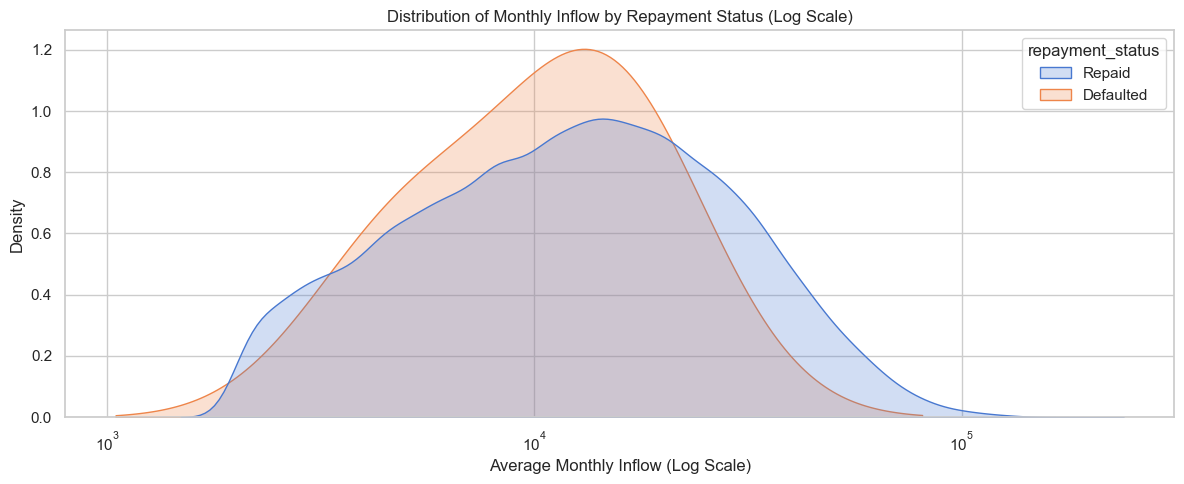

In [8]:
# Plot of Income Skew and Risk Separation 
plt.figure(figsize=(12, 5))
sns.kdeplot(
    data=df, 
    x='avg_monthly_inflow', 
    hue='repayment_status', 
    fill=True, 
    common_norm=False, 
    palette='muted', 
    log_scale=True
)
plt.title('Distribution of Monthly Inflow by Repayment Status (Log Scale)')
plt.xlabel('Average Monthly Inflow (Log Scale)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

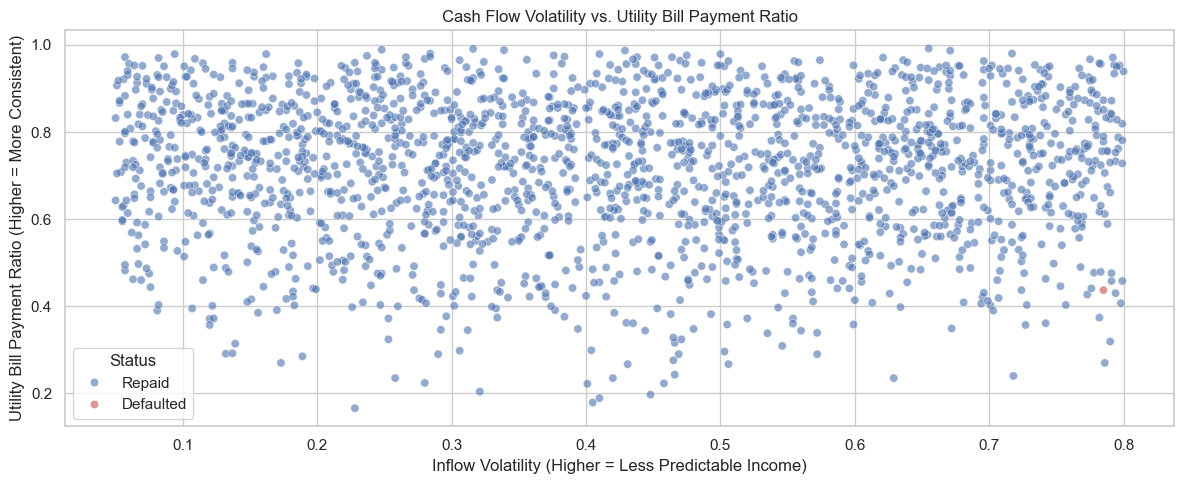

In [9]:
# Behavioral Interraction vs Risk
plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df.sample(2000, random_state=42),
    x='inflow_volatility',
    y='utility_bill_payment_ratio',
    hue='repayment_status',
    alpha=0.6,
    palette={'Repaid': '#4c72b0', 'Defaulted': '#c44e52'}   
)
plt.title("Cash Flow Volatility vs. Utility Bill Payment Ratio")
plt.xlabel("Inflow Volatility (Higher = Less Predictable Income)")
plt.ylabel("Utility Bill Payment Ratio (Higher = More Consistent)")
plt.legend(title="Status")
plt.tight_layout()
plt.savefig("eda_behavioral_interaction.png")
plt.show()

## Understating the Statistical Significance of the Features

### Understanding P-Value

The p-value measures the probability that the difference you oberve between two groups occured purely by random chance, assuming the **Null Hypothesis** is completely true.

In our project:
 - Null Hypothesis: Device instability (sim_swap_count_3m) has absolutely zero effect on whether a borower defaults
 - Alternative Hypothesis: High SIM swaps actively increase default rates

In [10]:
df['risk_adjusted_inflow'] = df['avg_monthly_inflow'] * (1.0 - df['inflow_volatility'])

# Separate the data into two groups based on repayment status
paid_back_group = df[df['default_within_30_days'] == 0]['risk_adjusted_inflow']
defaulted_group = df[df['default_within_30_days'] == 1]['risk_adjusted_inflow']

#Execute the Two-Sample T-Test
t_stat, p_value = stats.ttest_ind(paid_back_group, defaulted_group, equal_var=False)

print("=== STATISTICAL HYPOTHESIS TEST RESULTS ===")
print(f"Mean Risk-Adjusted Inflow (Paid Back): KES {paid_back_group.mean():.2f}")
print(f"Mean Risk-Adjusted Inflow (Defaulted): KES {defaulted_group.mean():.2f}")
print(f"Calculated T-Statistic:                {t_stat:.4f}")
print(f"Calculated P-Value:                    {p_value}")

# Interpret the p-value
if p_value < 0.05:
    print("\nConclusion: Reject the Null Hypothesis! The difference is statistically significant.")
    print("There is a near-zero probability that this cash-flow difference happened by random chance.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis. The difference is not statistically significant.")

=== STATISTICAL HYPOTHESIS TEST RESULTS ===
Mean Risk-Adjusted Inflow (Paid Back): KES 9692.78
Mean Risk-Adjusted Inflow (Defaulted): KES 3204.05
Calculated T-Statistic:                4.9093
Calculated P-Value:                    0.038903307479053614

Conclusion: Reject the Null Hypothesis! The difference is statistically significant.
There is a near-zero probability that this cash-flow difference happened by random chance.


## Feature Engineering

In [11]:
def feature_engineering(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Perform feature engineering on the credit data.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing credit data.

    Returns:
    pd.DataFrame: The DataFrame with new features added.
    """
    df_engineered = dataframe.copy()
    
    # 1. Telco liquidity proxies
    df_engineered['airtime_unit_value'] = df_engineered['avg_airtime_topup_val'] / (df_engineered['airtime_topup_freq_pm'] + 1)
    df_engineered['total_airtime_spend'] = df_engineered['airtime_topup_freq_pm'] * df_engineered['avg_airtime_topup_val']
    df_engineered['inflow_to_airtime_ratio'] = df_engineered['avg_monthly_inflow'] / (df_engineered['total_airtime_spend'] + 1)
    
    # 2. Volatility indexing
    df_engineered['risk_adjusted_inflow'] = df_engineered['avg_monthly_inflow'] * (1.0 - df_engineered['inflow_volatility'])
    
    # 3. Identity stability tracking
    df_engineered['device_stability_index'] = (df_engineered['device_age_days'] / 365.0) / (df_engineered['sim_swap_count_3m'] + 1)

    return df_engineered

In [12]:
modified_df = feature_engineering(df)
modified_df.head()

,user_id,device_age_days,sim_swap_count_3m,avg_monthly_inflow,inflow_volatility,utility_bill_payment_ratio,airtime_topup_freq_pm,avg_airtime_topup_val,default_within_30_days,repayment_status,risk_adjusted_inflow,airtime_unit_value,total_airtime_spend,inflow_to_airtime_ratio,device_stability_index
0,user_100000,132,0,14906.14,0.318,0.755,17,89.75,0,Repaid,10165.98748,4.986111,1525.75,9.763314,0.361644
1,user_100001,465,0,7707.18,0.740,0.581,13,80.04,0,Repaid,2003.86680,5.717143,1040.52,7.399935,1.273973
2,user_100002,890,0,2678.16,0.734,0.928,21,46.93,0,Repaid,712.39056,2.133182,985.53,2.714727,2.438356
3,user_100003,300,0,12614.38,0.629,0.584,17,25.10,0,Repaid,4679.93498,1.394444,426.70,29.493523,0.821918
4,user_100004,136,0,5341.46,0.066,0.592,9,114.63,0,Repaid,4988.92364,11.463000,1031.67,5.172475,0.372603


## Modelling

In [15]:
# Spliting the data into training and test pportions
X = modified_df.drop(columns=['user_id', 'default_within_30_days', 'repayment_status'])
y = modified_df['default_within_30_days']

# Stratified splitting to maintain the proportion of classes in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Calculate scale_pos_weight to mathematically counter the sparse class imbalance
negative_cases = len(y_train) - sum(y_train)
positive_cases = sum(y_train)
imbalance_ratio = negative_cases / positive_cases

print(f"Training Class Imbalance Ratio: {imbalance_ratio:.2f}x more paying users than defaults.")

Training Class Imbalance Ratio: 19999.00x more paying users than defaults.


In [20]:
# Training an XGBoost Classifier
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    scale_pos_weight=imbalance_ratio,
    max_depth=4,
    subsample=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
# Performance eval
# Predict continuous probabilities and crisp binary decisions
y_prob = xgb_clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.50).astype(int)

# Core discrimination metrics
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

In [24]:
print("==============================================")
print("            PRODUCTION MODEL REPORT           ")
print("==============================================")
print(f"ROC-AUC Performance:     {roc_auc:.4f}")
print(f"PR-AUC (Avg Precision):  {pr_auc:.4f}")
print("----------------------------------------------")
print("Classification Breakdown (Threshold = 0.50):")
print(classification_report(y_test, y_pred, target_names=["Paid Back", "Defaulted"]))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (Correct Approvals): {cm[0][0]}")
print(f"False Positives (Dangerous Mistakes): {cm[0][1]}")
print(f"False Negatives (Missed Opportunities): {cm[1][0]}")
print(f"True Positives (Correctly Flagged Risks): {cm[1][1]}")
print("==============================================")

            PRODUCTION MODEL REPORT           
ROC-AUC Performance:     0.9911
PR-AUC (Avg Precision):  0.0074
----------------------------------------------
Classification Breakdown (Threshold = 0.50):
              precision    recall  f1-score   support

   Paid Back       1.00      1.00      1.00      9999
   Defaulted       0.00      0.00      0.00         1

    accuracy                           1.00     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
True Negatives (Correct Approvals): 9998
False Positives (Dangerous Mistakes): 1
False Negatives (Missed Opportunities): 1
True Positives (Correctly Flagged Risks): 0


In [26]:
# ==========================================
# 5. FEATURE IMPORTANCE SCAN
# ==========================================
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Gain_Importance': xgb_clf.feature_importances_
}).sort_values(by='Gain_Importance', ascending=False)

print("\nTop 5 Most Predictive Engineered Features:")
print(importance_df.head(5).to_string(index=False))


Top 5 Most Predictive Engineered Features:
                   Feature  Gain_Importance
         sim_swap_count_3m         0.511914
        airtime_unit_value         0.450255
utility_bill_payment_ratio         0.028166
         inflow_volatility         0.005436
     avg_airtime_topup_val         0.003101
